In [1]:
import mediapipe as mp
import cv2
import numpy as np
from pathlib import Path

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

# Índices de landmarks que rodean cada ojo (estándar de MediaPipe Face Mesh)
OJO_IZQUIERDO = [33, 133, 160, 159, 158, 157, 173, 154, 153, 145, 144, 163, 7, 246, 161, 246]
OJO_DERECHO = [362, 263, 387, 386, 385, 384, 398, 381, 380, 374, 373, 390, 249, 466, 388, 466]

def recortar_ojo(frame, landmarks, indices, margen=0.35):
    h, w = frame.shape[:2]
    puntos = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in indices])

    x_min, y_min = puntos.min(axis=0)
    x_max, y_max = puntos.max(axis=0)

    ancho, alto = x_max - x_min, y_max - y_min
    x_min -= ancho * margen
    x_max += ancho * margen
    y_min -= alto * margen
    y_max += alto * margen

    x_min, y_min = max(0, int(x_min)), max(0, int(y_min))
    x_max, y_max = min(w, int(x_max)), min(h, int(y_max))

    return frame[y_min:y_max, x_min:x_max]

In [2]:
def preparar_para_onnx(recorte_bgr):
    img = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0

    media = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    desv = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = (img - media) / desv

    img = img.transpose(2, 0, 1)      # de (alto, ancho, canales) a (canales, alto, ancho)
    img = np.expand_dims(img, axis=0)  # agrega la dimensión de "lote": (1, 3, 224, 224)
    return img.astype(np.float32)

In [3]:
import onnxruntime as ort

# Cargar MediaPipe
opts = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="../models/face_landmarker.task"),
    running_mode=RunningMode.IMAGE,
    num_faces=1,
)
detector = FaceLandmarker.create_from_options(opts)

# Cargar el modelo ONNX de ojos
sesion = ort.InferenceSession("../models/mobilenetv2_ojos.onnx", providers=["CPUExecutionProvider"])
nombre_entrada = sesion.get_inputs()[0].name

# Probar con tu foto de prueba
ruta_imagen = "../data/raw/prueba.jpg"
frame = cv2.imread(ruta_imagen)

img_mp = mp.Image.create_from_file(ruta_imagen)
resultado = detector.detect(img_mp)

if len(resultado.face_landmarks) == 0:
    print("No se detectó ningún rostro.")
else:
    landmarks = resultado.face_landmarks[0]

    for nombre, indices in [("Ojo izquierdo", OJO_IZQUIERDO), ("Ojo derecho", OJO_DERECHO)]:
        recorte = recortar_ojo(frame, landmarks, indices)
        entrada = preparar_para_onnx(recorte)

        salida = sesion.run(None, {nombre_entrada: entrada})[0]
        probabilidad = 1 / (1 + np.exp(-salida.flatten()[0]))
        estado = "ABIERTO" if probabilidad > 0.5 else "CERRADO"

        print(f"{nombre}: {estado} (probabilidad de abierto: {probabilidad:.3f})")

Ojo izquierdo: ABIERTO (probabilidad de abierto: 0.980)
Ojo derecho: ABIERTO (probabilidad de abierto: 0.900)


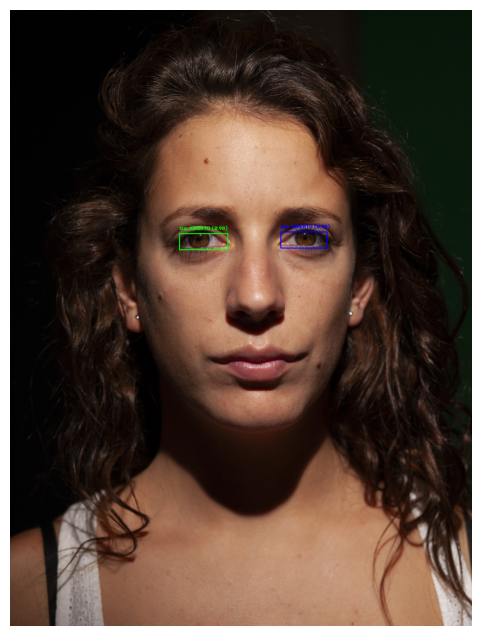

In [4]:
from matplotlib import pyplot as plt

frame_dibujado = frame.copy()
h, w = frame.shape[:2]

for nombre, indices, color in [("Izq", OJO_IZQUIERDO, (0, 255, 0)), ("Der", OJO_DERECHO, (255, 0, 0))]:
    puntos = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in indices])
    x_min, y_min = puntos.min(axis=0).astype(int)
    x_max, y_max = puntos.max(axis=0).astype(int)

    recorte = recortar_ojo(frame, landmarks, indices)
    entrada = preparar_para_onnx(recorte)
    salida = sesion.run(None, {nombre_entrada: entrada})[0]
    probabilidad = 1 / (1 + np.exp(-salida.flatten()[0]))
    estado = "ABIERTO" if probabilidad > 0.5 else "CERRADO"

    cv2.rectangle(frame_dibujado, (x_min, y_min), (x_max, y_max), color, 2)
    cv2.putText(frame_dibujado, f"{nombre}: {estado} ({probabilidad:.2f})",
                (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(frame_dibujado, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [5]:
# Índices de landmarks de la boca (MediaPipe Face Mesh)
BOCA = {
    "izq": 61, "der": 291,           # comisuras (horizontal)
    "sup_ext": 13, "inf_ext": 14,    # labio superior/inferior, centro
    "sup1": 82, "inf1": 312,
    "sup2": 87, "inf2": 317,
}

def calcular_mar(landmarks, frame_shape):
    h, w = frame_shape[:2]
    def punto(idx):
        return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

    horizontal = np.linalg.norm(punto(BOCA["izq"]) - punto(BOCA["der"]))
    vertical1 = np.linalg.norm(punto(BOCA["sup_ext"]) - punto(BOCA["inf_ext"]))
    vertical2 = np.linalg.norm(punto(BOCA["sup1"]) - punto(BOCA["inf1"]))
    vertical3 = np.linalg.norm(punto(BOCA["sup2"]) - punto(BOCA["inf2"]))

    mar = (vertical1 + vertical2 + vertical3) / (3 * horizontal)
    return mar

mar = calcular_mar(landmarks, frame.shape)
UMBRAL_MAR = 0.6  # valor de referencia típico en la literatura; ajustaremos con tus datos
print(f"MAR: {mar:.3f} → {'BOSTEZO' if mar > UMBRAL_MAR else 'normal'}")

MAR: 0.157 → normal
